### Supp. Correct rate by representation with or without (previous arm representations or current)

In [15]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
from spyglass.shijiegu.changeOfMind import nodes, color_by_rat
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta

In [4]:
def return_save_name(animal, parameter_name, d1, d2, minimum_duration, min_posterior, proportion = 0.1, use_1d = 1):
    save_name = f'{animal.lower()}_{parameter_name}_{d1}_{d2}_t{minimum_duration}_minp{min_posterior}_p{proportion}_use1d{use_1d}_remoteGLM'
    return save_name

In [5]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

# encoding_set = 'all_maze'
# classifier_param_name = 'default_decoding_gpu_4armMaze'

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']#'20231111']
seq_animals[animal] = 'rev2'

In [13]:
parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
hpd = False

q_long = {"proportion": 0.1,
                 "minimum_duration":minimum_duration_long,
                  "parameter":parameter_name_long_theta,
                  "local_parameter":f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"
                 }

In [8]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

def sd_err(arr):
    N = len(arr)
    p = np.sum(arr)/ N
    return np.sqrt((p * (1-p) / N))

def plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = False, draw_text = True):
    std = [sd_err(data1), sd_err(data2)]
    mean = [np.mean(data1), np.mean(data2)]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.25, hatch=['', '////'],color = color_by_rat[animal], alpha=0.8)
    if draw_text:
        if len(data1) == 0:
            ax.text(animal_ind - 0.15, 0 + 0.05, 0, fontsize = 6)
        else:
            ax.text(animal_ind - 0.15, mean[0]+std[0] + 0.05, len(data1), fontsize = 6)
        ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.05, len(data2), fontsize = 6)
        
    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = fisher_exact(table, alternative = "greater")
    p_value = res.pvalue
    print("p_value", p_value)
    if p_value < 0.05 and draw_annotation:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax, p_value

def plot_one_axis3(data1, data2, data3, animal_ind, ax, animal, draw_annotation = False, draw_text = True):
    std = [sd_err(data1), sd_err(data2), sd_err(data3)]
    mean = [np.mean(data1), np.mean(data2), np.mean(data3)]
    ax.bar([0 + animal_ind,
                0.2 + animal_ind,
                   0.4 + animal_ind],
           mean, yerr=std, width=0.18, hatch=['', '\\\\', "////"],
           color = color_by_rat[animal], alpha=0.7)
    if draw_text:
        ax.text(animal_ind - 0.1, mean[0]+std[0], len(data1), fontsize = 6)
        ax.text(animal_ind + 0.2 - 0.1, mean[1]+std[1] + 0.05, len(data2), fontsize = 6)
        ax.text(animal_ind + 0.4 - 0.1, mean[2]+std[2] + 0.05, len(data3), fontsize = 6)
        
    return ax

In [11]:
tally_dict

[('lewis20240105_.nwb', '02_Rev2Session1', 42, nan, 0),
 ('lewis20240105_.nwb', '02_Rev2Session1', 50, array([6]), 1),
 ('lewis20240105_.nwb', '02_Rev2Session1', 62, nan, 1),
 ('lewis20240105_.nwb', '02_Rev2Session1', 66, nan, 1),
 ('lewis20240105_.nwb', '02_Rev2Session1', 70, array([6]), 0),
 ('lewis20240105_.nwb', '02_Rev2Session1', 88, nan, 1),
 ('lewis20240105_.nwb', '02_Rev2Session1', 98, nan, 0),
 ('lewis20240105_.nwb', '04_Rev2Session2', 5, nan, 1),
 ('lewis20240105_.nwb', '04_Rev2Session2', 30, array([1, 6]), 1),
 ('lewis20240105_.nwb', '04_Rev2Session2', 43, nan, 1),
 ('lewis20240105_.nwb', '04_Rev2Session2', 81, array([1, 6]), 1),
 ('lewis20240105_.nwb', '06_Rev2Session3', 12, nan, 0),
 ('lewis20240105_.nwb', '06_Rev2Session3', 22, nan, 1),
 ('lewis20240105_.nwb', '06_Rev2Session3', 29, array([9]), 1),
 ('lewis20240105_.nwb', '06_Rev2Session3', 36, nan, 0),
 ('lewis20240105_.nwb', '06_Rev2Session3', 51, nan, 1),
 ('lewis20240105_.nwb', '08_Rev2Session4', 16, array([7]), 0),
 

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.8829699712052653
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.21442680419321136
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.8970588235294118
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.8866246834114782
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.21534562130389692


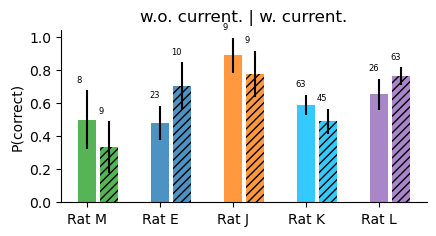

In [27]:
# Plotting
fig, ax = plt.subplots(figsize=(5, 3))
feature_names = ["constant", "previous", "previously_rewarded", "future", "future_correct","same side","switch side"]

animal_ind = 0
animals = ["molly", "eliot","julio","klein","lewis"]#["lewis","molly","julio","klein"]
num_of_com = {} #number of change of mind considered
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                 minimum_duration = minimum_duration, min_posterior = min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]
    tally_dict = data["tally_dict"]

    Y_with= []
    Y_wo = []
    Z = np.array([d[-1] == 1 for d in tally_dict]) #reward or not
    for trial in range(len(features_all)):
        nwb_file_name, sessionName, trialID, current_arm, reward = tally_dict[trial]
        # for now, only trials w 1 com event
        #if np.all(np.isnan(current_arm)):
        #    continue
        x = features_all[trial] > 0
        y = np.array(response_all[trial])

        # y_prev_bool = np.sum(y[x[:,0]]) > 0 # contain rep of previous arm
        # if y_prev_bool:
        #     Y_with_prev.append(Z[trial])
        # else:
        #     Y_no_prev.append(Z[trial])

        q_long["nwb_file_name"] = tally_dict[trial][0]
        q_long["epoch"] = int(sessionName[:2])
        if len(ChangeofMindTheta() & q_long) > 0:
            long_df = ChangeofMindTheta().fetch1_dataframe(q_long)         # trials with long theta
        else:
            continue
        y_current_bool = long_df.loc[trialID].long_theta
        if y_current_bool:
            Y_with.append(reward)
        else:
            Y_wo.append(reward)


    Y_with = np.array(Y_with).astype("int")
    Y_wo = np.array(Y_wo).astype("int")
    
    plot_one_axis(Y_wo, Y_with, animal_ind, ax, animal, draw_annotation = True, draw_text = True)
    
    animal_ind += 1

ax.set_title('w.o. current. | w. current.')

ax.set_xticks(np.arange(len(animals)));
ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
ax.set_ylabel("P(correct)")
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
#plt.show()

fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

#file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/wo_prev_rep.pdf"
#fig.savefig(file_path, format="pdf", bbox_inches="tight")

### GLM

In [19]:
GLM_xy = []
animals = ["molly", "eliot","julio","klein","lewis"]#["lewis","molly","julio","klein"]
num_of_com = {} #number of change of mind considered
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                 minimum_duration = minimum_duration, min_posterior = min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]
    tally_dict = data["tally_dict"]

    Y_with_prev = []
    Y_no_prev = []
    for trial in range(len(features_all)):
        x = features_all[trial] > 0
        y = np.array(response_all[trial])

        y_prev_bool = np.sum(y[x[:,0]]) > 0 # contain rep of previous arm
        visit_prev = np.sum(x[:,2][x[:,0]]) > 0
        if y_prev_bool:
            Y_with_prev.append(visit_prev)
        else:
            Y_no_prev.append(visit_prev)

    Y_with_prev = np.array(Y_with_prev).astype("int")
    Y_no_prev = np.array(Y_no_prev).astype("int")
    
    animal_category = [a == animal for a in animals]
    for ind in range(len(Y_with_prev)):
        GLM_xy.append(animal_category + [1, Y_with_prev[ind]])

    for ind in range(len(Y_no_prev)):
        GLM_xy.append(animal_category + [0, Y_no_prev[ind]])
    
GLM_xy = np.array(GLM_xy).astype("int")

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM


In [20]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["rep. prev"] = GLM_xy[:,(len(animals))]

In [21]:
X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_xy[:,-1].astype("int").reshape((-1,1))

"""b) Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result2 = logistic_model.fit()

# 3. View the model summary
print("===== start ===== ")
print("\n \n Mixed Logistics \n",logistic_result2.summary())
print("===== end ===== ")

         Current function value: 0.211097
         Iterations: 35
===== start ===== 

 
 Mixed Logistics 
                            Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  268
Model:                          Logit   Df Residuals:                      262
Method:                           MLE   Df Model:                            5
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.1067
Time:                        08:53:41   Log-Likelihood:                -56.574
converged:                      False   LL-Null:                       -63.331
Covariance Type:            nonrobust   LLR p-value:                   0.01901
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.9414        nan        nan        nan         nan         nan
Rat M        -17.7424   

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
